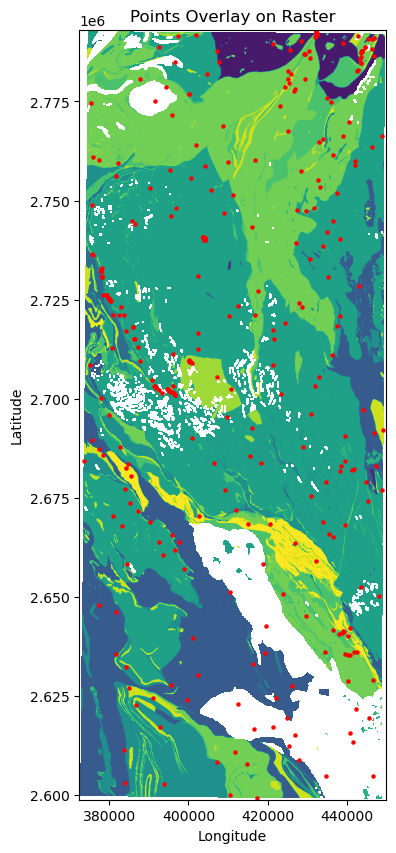

           X           Y  Label  BP1.tif  BP2.tif     BP3.tif     BP4.tif  \
0  440786.81  2642077.56      1    255.0      0.0   18.309561  208.462555   
1  436430.60  2641788.57      1    204.0      0.0   25.893629  196.377960   
2  439430.23  2635532.39      1    204.0      0.0   17.336666  211.162735   
3  441866.23  2636260.49      1    204.0      0.0   90.723312  211.475815   
4  442487.62  2636011.97      1    187.0      0.0  108.053688  208.533401   

      BP5.tif     BP6.tif     BP7.tif     BP8.tif     BP9.tif    BP10.tif  \
0  152.207352  114.003777  234.128418  228.794464  255.000000  189.991425   
1  154.880051   99.249771  234.961914  192.509888  218.571426  189.299408   
2  151.585327  118.567696  229.825272  230.810272  241.339279  161.381027   
3  154.378815   95.339821  230.810394  208.636368  250.446426  172.840439   
4  160.164917  102.080162  230.156189  176.383408  250.446426  167.205093   

     BP11.tif    BP12.tif    BP13.tif   BP14.tif    BP15.tif    BP16.tif  

In [2]:
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os

# Directory containing raster files

raster_dir = "C:/Users/AMD NR/Untitled Folder/RajML_py/Copper_package"  # Update this path

# List of raster file names
raster_files = [f"BP{i}.tif" for i in range(1, 18)]

# Load the points from the CSV file
points_df = pd.read_csv("CuTS01.csv")

# Create a DataFrame to store results
results_df = points_df.copy()

# Iterate through each raster file
for raster_file in raster_files:
    raster_path = os.path.join(raster_dir, raster_file)
    try:
        with rasterio.open(raster_path) as raster:
            # Extract raster values at the point locations
            coordinates = [(x, y) for x, y in zip(points_df['X'], points_df['Y'])]
            raster_values = [val[0] for val in raster.sample(coordinates)]
            
            # Add raster values to the DataFrame
            results_df[raster_file] = raster_values
    except rasterio.errors.RasterioIOError:
        # Handle the case where the raster file cannot be opened
        results_df[raster_file] = None
# Plotting example: plotting the first raster
fig, ax = plt.subplots(figsize=(10, 10))
if raster_files:
    # Load the first raster to show as an example
    with rasterio.open(os.path.join(raster_dir, raster_files[0])) as raster:
        rasterio.plot.show(raster, ax=ax)
    
    # Overlay the points on the raster plot
    ax.scatter(points_df['X'], points_df['Y'], color='red', s=5)

# Show the plot
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Points Overlay on Raster')
plt.show()

# Display the first few rows with the extracted raster values
print(results_df.head())

# Optionally, save the results to a CSV file
results_df.to_csv("extracted_raster_values.csv", index=False)


In [3]:
#restructuring the results_dataframe for random Forest classifcation
# Drop the first two columns and send label column to the last 
#ML_df is the master dataframe for classification 
ML_df = results_df.drop(columns=['X', 'Y'])
# Extract the third column (Feature3 in this example)
third_column = results_df['Label']

# Drop the third column from the original DataFrame
ML_df = ML_df.drop(columns=['Label'])

# Add the third column to the end of the DataFrame
ML_df['Label'] = third_column 

print(ML_df)
ML_df.to_csv('Cu_ML_base.csv', index=False)

     BP1.tif    BP2.tif     BP3.tif     BP4.tif     BP5.tif     BP6.tif  \
0      255.0   0.000000   18.309561  208.462555  152.207352  114.003777   
1      204.0   0.000000   25.893629  196.377960  154.880051   99.249771   
2      204.0   0.000000   17.336666  211.162735  151.585327  118.567696   
3      204.0   0.000000   90.723312  211.475815  154.378815   95.339821   
4      187.0   0.000000  108.053688  208.533401  160.164917  102.080162   
..       ...        ...         ...         ...         ...         ...   
375    136.0   9.194156   85.000000  189.425247   81.142776   86.584282   
376    153.0  50.293861  200.715225  197.226913  154.641983  109.193886   
377    204.0  60.451672    0.000000  200.917877  115.527779   61.355717   
378    153.0  25.243713   71.480911  202.988800  126.657784   81.266235   
379    204.0   5.701973  148.514236  199.587234  170.033035  106.757309   

        BP7.tif     BP8.tif     BP9.tif    BP10.tif    BP11.tif    BP12.tif  \
0    234.128418  228

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import numpy as np

In [5]:
# Example DataFrame loading
# df = pd.read_csv('your_data.csv')

# Assume the last column is the label
X = ML_df.iloc[:, :-1]  # Features
y = ML_df.iloc[:, -1]   # Labels

In [6]:
# Split the data into training (70%) and validation (30%) sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


In [7]:
# Split the validation set into two halves (50% each)
X_valid1, X_valid2, y_valid1, y_valid2 = train_test_split(X_valid, y_valid, test_size=0.50, stratify=y_valid, random_state=42)

In [8]:
# Initialize and train the Random Forest classifier
clf = RandomForestClassifier(n_estimators=500,oob_score=True,random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, oob_score=True, random_state=42)

In [9]:
# Predict on the first half of the validation set
y_pred_valid1 = clf.predict(X_valid1)
y_proba_valid1 = clf.predict_proba(X_valid1)[:, 1]  # Probabilities for ROC AUC

# Predict on the second half of the validation set
y_pred_valid2 = clf.predict(X_valid2)
y_proba_valid2 = clf.predict_proba(X_valid2)[:, 1]  # Probabilities for ROC AUC

In [10]:
# Evaluation metrics for the first half of the validation set
print("Evaluation on Validation Set 1")
print("Confusion Matrix:\n", confusion_matrix(y_valid1, y_pred_valid1))
print("Classification Report:\n", classification_report(y_valid1, y_pred_valid1))
print("Accuracy Score:", accuracy_score(y_valid1, y_pred_valid1))
print("ROC AUC Score:", roc_auc_score(y_valid1, y_proba_valid1))

# Evaluation metrics for the second half of the validation set
print("Evaluation on Validation Set 2")
print("Confusion Matrix:\n", confusion_matrix(y_valid2, y_pred_valid2))
print("Classification Report:\n", classification_report(y_valid2, y_pred_valid2))
print("Accuracy Score:", accuracy_score(y_valid2, y_pred_valid2))
print("ROC AUC Score:", roc_auc_score(y_valid2, y_proba_valid2))

#Out of bag error 
# Obtain the OOB error 
oob_error = 1 - clf.oob_score_ 
  
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

Evaluation on Validation Set 1
Confusion Matrix:
 [[18  1]
 [ 3 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.94      0.84      0.89        19

    accuracy                           0.89        38
   macro avg       0.90      0.89      0.89        38
weighted avg       0.90      0.89      0.89        38

Accuracy Score: 0.8947368421052632
ROC AUC Score: 0.9556786703601108
Evaluation on Validation Set 2
Confusion Matrix:
 [[17  2]
 [ 2 17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.89      0.89      0.89        19

    accuracy                           0.89        38
   macro avg       0.89      0.89      0.89        38
weighted avg       0.89      0.89      0.89        38

Accuracy Score: 0.8947368421052632
ROC AUC Score: 0.9390581717451523
OOB error: 0.066


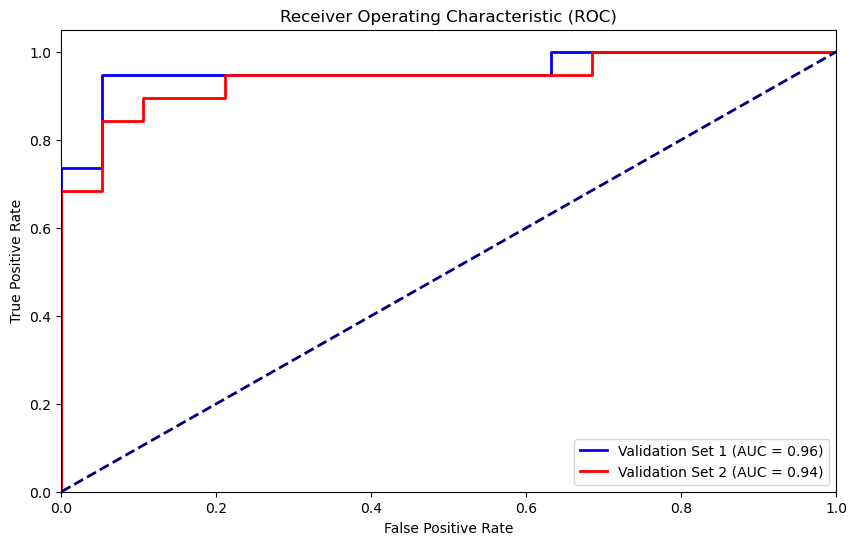

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming you have the following variables
# y_valid1: True labels for the first half of the validation set
# y_proba_valid1: Predicted probabilities for the positive class for the first half
# y_valid2: True labels for the second half of the validation set
# y_proba_valid2: Predicted probabilities for the positive class for the second half

# Compute ROC curve for Validation Set 1
fpr1, tpr1, _ = roc_curve(y_valid1, y_proba_valid1)
roc_auc1 = roc_auc_score(y_valid1, y_proba_valid1)

# Compute ROC curve for Validation Set 2
fpr2, tpr2, _ = roc_curve(y_valid2, y_proba_valid2)
roc_auc2 = roc_auc_score(y_valid2, y_proba_valid2)

# Plot ROC curve
plt.figure(figsize=(10, 6))

# ROC curve for Validation Set 1
plt.plot(fpr1, tpr1, color='blue', lw=2, label=f'Validation Set 1 (AUC = {roc_auc1:.2f})')

# ROC curve for Validation Set 2
plt.plot(fpr2, tpr2, color='red', lw=2, label=f'Validation Set 2 (AUC = {roc_auc2:.2f})')

# Plot diagonal line (no discrimination line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Customize plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# Show plot
plt.savefig('plot.png', format='png', bbox_inches='tight')
plt.show()

In [12]:
import joblib  # This is the key library to export models
joblib_file = "random_forest_model.joblib"
joblib.dump(clf, joblib_file)
print(f"Random Forest model saved as: {joblib_file}")


Random Forest model saved as: random_forest_model.joblib


In [13]:
import rasterio
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from joblib import load

# Load the trained model
rf_model = load('random_forest_model.joblib')  # Replace with your model file

# Define a function to read rasters and stack them
def stack_rasters(raster_paths):
    """Stack multiple raster files (features) into a single 3D array."""
    raster_stack = []
    min_height = float('inf')
    min_width = float('inf')

    # First, determine the minimum dimensions
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            height, width = src.shape
            min_height = min(min_height, height)
            min_width = min(min_width, width)

    # Now read and trim each raster
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            data = src.read(1)  # Read the first band of each raster
            trimmed_data = data[:min_height, :min_width]  # Trim to the minimum size
            raster_stack.append(trimmed_data)

    # Convert list of 2D arrays to a 3D numpy array
    return np.stack(raster_stack, axis=-1)

# Directory containing raster files
raster_dir = "C:/Users/AMD NR/Untitled Folder/RajML_py/Copper_package"

# Paths to the 17 raster files (assumed to be named BP1.tif, BP2.tif, ..., BP17.tif)
raster_paths = [os.path.join(raster_dir, f'BP{i}.tif') for i in range(1, 18)]

# Load and stack rasters
try:
    stacked_rasters = stack_rasters(raster_paths)  # Shape: (min_height, min_width, num_features)
except ValueError as e:
    print(e)
    exit()

# Reshape data to match the model's input
height, width, num_features = stacked_rasters.shape
reshaped_data = stacked_rasters.reshape(-1, num_features)  # Shape: (num_pixels, num_features)

# Handle NaN values
reshaped_data = reshaped_data[~np.isnan(reshaped_data).any(axis=1)]

# Apply the Random Forest model to predict for each pixel
predictions = rf_model.predict(reshaped_data)

# Reshape predictions back to the original image shape
predictions_reshaped = predictions.reshape(height, width)

# Save the prediction as a new raster
output_raster_path = os.path.join(raster_dir, "output_prediction.tif")

with rasterio.open(raster_paths[0]) as src:
    meta = src.meta  # Get the metadata of the original raster
    meta.update(count=1, dtype='int16', nodata=-9999)  # Update metadata for the prediction raster

    # Write the prediction raster
    with rasterio.open(output_raster_path, 'w', **meta) as dst:
        dst.write(predictions_reshaped.astype('int16'), 1)  # Save as int16

print("Prediction raster saved at:", output_raster_path)


C:\Users\AMD NR\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction raster saved at: C:/Users/AMD NR/Untitled Folder/RajML_py/Copper_package\output_prediction.tif


Feature 3: 0.13708453245695024
Feature 11: 0.13173782295442066
Feature 9: 0.08585962781132066
Feature 14: 0.07021119773478328
Feature 5: 0.06786328409659201
Feature 15: 0.05748541091285496
Feature 10: 0.05141898662567988
Feature 13: 0.05133684065365755
Feature 17: 0.05020381037839682
Feature 4: 0.04975946821118409
Feature 6: 0.04728319198543333
Feature 2: 0.04121345654769824
Feature 16: 0.03883457001804986
Feature 12: 0.03596239383825868
Feature 7: 0.032661707739320756
Feature 1: 0.029077329744016334
Feature 8: 0.02200636829138253


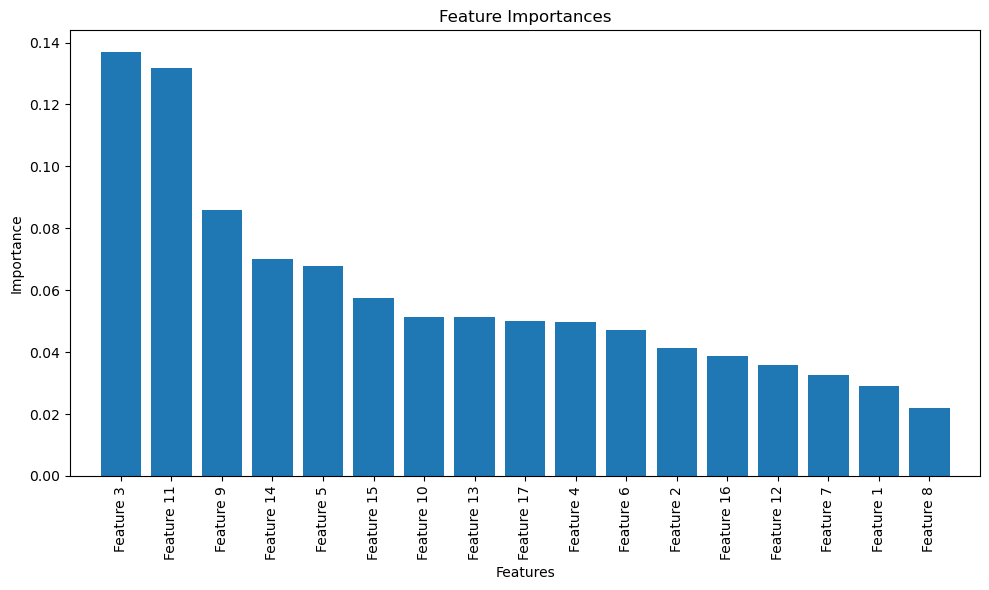

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `rf_model` is your trained RandomForestClassifier
# and `X_train` is the training data used to fit the model

# Get feature importances
importances = rf_model.feature_importances_

# Assuming you have feature names; if not, you can create a simple list
feature_names = [f'Feature {i+1}' for i in range(X_train.shape[1])]

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

for idx in indices:
    print(f"{feature_names[idx]}: {importances[idx]}")

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), np.array(feature_names)[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()
